In [18]:
#EXERCISE1

import io
import zipfile
import pandas as pd
import requests
from sklearn.preprocessing import MinMaxScaler, StandardScaler

zip_url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/titanic%20dataset.zip"
response = requests.get(zip_url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    df = pd.read_csv(z.open("titanic dataset/train.csv"))

scaler_std = StandardScaler()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age_scaled"] = scaler_std.fit_transform(df[["Age"]])

scaler_minmax = MinMaxScaler()
df["Fare_scaled"] = scaler_minmax.fit_transform(df[["Fare"]])

In [19]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print(df.groupby("FamilySize")["Survived"].mean())
print(df.groupby("IsAlone")["Survived"].mean())

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


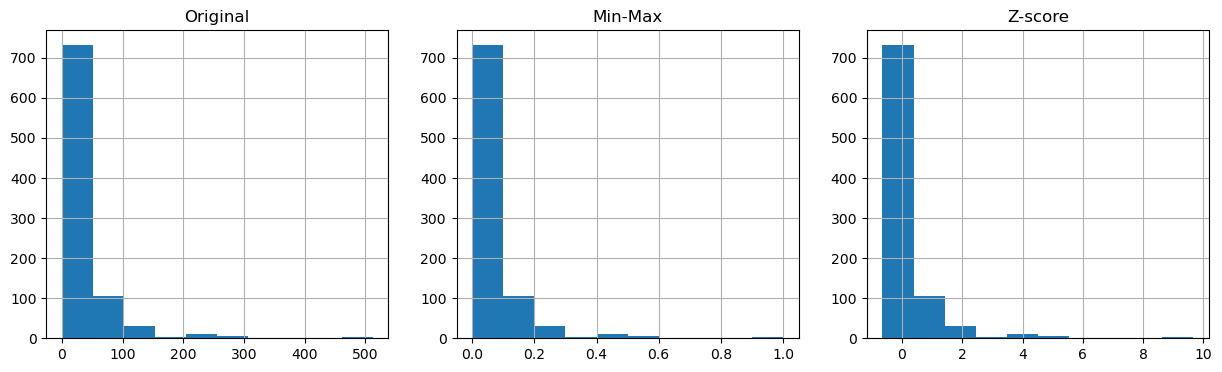

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["Fare"].hist(ax=axes[0])
axes[0].set_title("Original")

scaler_mm = MinMaxScaler()
df["Fare_mm"] = scaler_mm.fit_transform(df[["Fare"]])
df["Fare_mm"].hist(ax=axes[1])
axes[1].set_title("Min-Max")

scaler_z = StandardScaler()
df["Fare_z"] = scaler_z.fit_transform(df[["Fare"]])
df["Fare_z"].hist(ax=axes[2])
axes[2].set_title("Z-score")
plt.show()

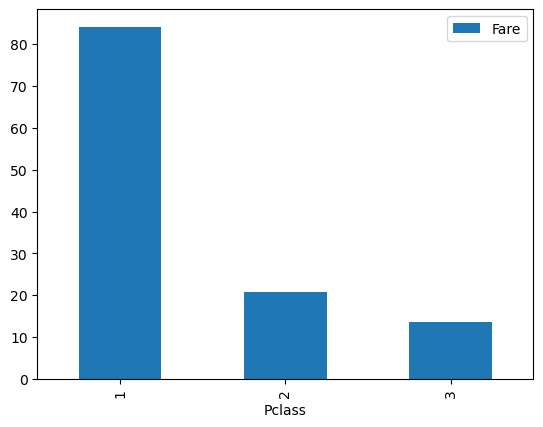

In [21]:
from sklearn.decomposition import PCA

df_numeric = df[["Age", "Fare", "FamilySize", "Pclass"]].dropna()

pca = PCA(n_components=2)
coords = pca.fit_transform(df_numeric)

df_agg = df.groupby("Pclass")["Fare"].mean().reset_index()

df_agg.plot(kind="bar", x="Pclass", y="Fare")
plt.show()

In [22]:
import io
import zipfile
import pandas as pd
import requests
from sklearn.preprocessing import MinMaxScaler

# Lien vers le fichier ZIP Superstore Sales Data transmis
zip_url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/Superstore%20Sales%20Data.zip"
response = requests.get(zip_url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Récupération automatique du fichier CSV à l'intérieur du ZIP
    csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
    # Lecture avec l'encodage 'latin1' souvent requis pour ce dataset de ventes
    df_superstore = pd.read_csv(z.open(csv_name), encoding="latin1")

# Initialisation du MinMaxScaler pour la mise à l'échelle entre 0 et 1
scaler = MinMaxScaler()

# Normalisation des colonnes 'Sales' et 'Profit'
df_superstore["Sales_normalized"] = scaler.fit_transform(
    df_superstore[["Sales"]]
)
df_superstore["Profit_normalized"] = scaler.fit_transform(
    df_superstore[["Profit"]]
)

# Affichage des premières lignes pour vérifier le résultat
print(
    df_superstore[
        ["Sales", "Sales_normalized", "Profit", "Profit_normalized"]
    ].head()
)

     Sales  Sales_normalized   Profit  Profit_normalized
0  408.300          0.018016  106.140           0.447076
1  120.366          0.005297   36.036           0.442402
2   66.120          0.002901   29.640           0.441976
3   44.865          0.001962  -26.055           0.438263
4  113.670          0.005002   37.770           0.442518


In [26]:
import io
import zipfile
import pandas as pd
import requests

# 1. Chargement du ZIP
zip_url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/Air%20Quality%20Data%20in%20India.zip"
response = requests.get(zip_url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
    df_air = pd.read_csv(z.open(csv_name), low_memory=False)

# 2. Passage en minuscules pour uniformiser
df_air.columns = df_air.columns.str.lower()

# --- VÉRIFICATION DES COLONNES ---
print("Colonnes disponibles dans ton fichier :", list(df_air.columns))
print("-" * 50)

# 3. Détection automatique de la colonne géographique (location, station, state ou city)
geo_col = None
for col in ["location", "station", "state", "city"]:
    if col in df_air.columns:
        geo_col = col
        break

if not geo_col:
    # Si aucun ne correspond, on prend la première colonne textuelle par défaut
    geo_col = df_air.select_dtypes(include=["object"]).columns[0]

print(f"-> Colonne géographique identifiée et utilisée : '{geo_col}'")

# 4. Traitement de la date
df_air["date"] = pd.to_datetime(df_air["date"], errors="coerce")
df_air = df_air.dropna(subset=["date"])
df_air["month"] = df_air["date"].dt.to_period("M")

# 5. Sélection dynamique des colonnes de polluants présentes dans le fichier
# (Certains fichiers ont 'pm2_5', d'autres 'pm2.5', 'so2', 'no2', etc.)
polluants_possibles = ["pm2_5", "pm2.5", "pm10", "no2", "so2", "rspm"]
polluants_presents = [c for c in polluants_possibles if c in df_air.columns]

print(f"-> Polluants identifiés et utilisés pour la moyenne : {polluants_presents}")
print("-" * 50)

# 6. Agrégation dynamique
df_monthly = (
    df_air.groupby([geo_col, "month"])[polluants_presents]
    .mean()
    .reset_index()
)

print(df_monthly.head())

Colonnes disponibles dans ton fichier : ['city', 'date', 'pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'aqi', 'aqi_bucket']
--------------------------------------------------
-> Colonne géographique identifiée et utilisée : 'city'
-> Polluants identifiés et utilisés pour la moyenne : ['pm2.5', 'pm10', 'no2', 'so2']
--------------------------------------------------
        city    month       pm2.5  pm10        no2        so2
0  Ahmedabad  2015-01   82.682500   NaN  26.846774  43.602903
1  Ahmedabad  2015-02  116.101600   NaN  31.315200  63.194000
2  Ahmedabad  2015-03  110.469333   NaN  27.937333  58.874333
3  Ahmedabad  2015-04  101.682000   NaN  20.754000  51.233333
4  Ahmedabad  2015-05   74.919355   NaN  17.325806  35.977419
